# Notebook 03 — Scaling, Weights, and Observation Matrices

PhosCrosstalk normalises raw measurements before fitting and assigns per-entry
weights to the loss function.  This notebook covers both steps.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Load data (reused across cells)
from phoscrosstalk.data_loader import load_site_data, load_rna_data, apply_scaling
from phoscrosstalk.weighting import build_weight_matrices

timepoints = list(range(1, 15))
sites, proteins, site_prot_idx, positions, t, Y, A_data, A_proteins = \
    load_site_data(SAMPLE_DIR / "protephospho.csv", timepoints)
gene_ids, t_rna, rna_matrix = load_rna_data(SAMPLE_DIR / "mrna.csv", timepoints=timepoints)


## 1 · Three scaling modes

| Mode | Formula | When to use |
|------|---------|-------------|
| `"none"` | `P = Y` (no change) | Already normalised data |
| `"minmax"` | `P[i,t] = (Y[i,t] − min_i) / (max_i − min_i)` | Bounded [0, 1] per site |
| `"log-minmax"` | `P[i,t] = (log1p(Y[i,t]) − min_i) / range_i` | Heavy-tailed / fold-change data |


In [3]:
# Apply each scaling mode and compare
P_none,    _, _  = apply_scaling(Y, mode="none")
P_minmax,  baselines_mm, amplitudes_mm = apply_scaling(Y, mode="minmax")
P_logmm,   baselines_lm, amplitudes_lm = apply_scaling(Y, mode="log-minmax")

print("Y (raw)      shape:", Y.shape,       "  min/max:", Y.min().round(4), "/", Y.max().round(4))
print("none         shape:", P_none.shape,  "  min/max:", P_none.min().round(4), "/", P_none.max().round(4))
print("minmax       shape:", P_minmax.shape,"  min/max:", P_minmax.min().round(4), "/", P_minmax.max().round(4))
print("log-minmax   shape:", P_logmm.shape, "  min/max:", P_logmm.min().round(4), "/", P_logmm.max().round(4))

print("\nbaselines (minmax, per site):", baselines_mm.round(4))
print("amplitudes (minmax, per site):", amplitudes_mm.round(4))


Y (raw)      shape: (9, 14)   min/max: 0.001 / 1.0
none         shape: (9, 14)   min/max: 0.001 / 1.0
minmax       shape: (9, 14)   min/max: 0.0 / 1.0
log-minmax   shape: (9, 14)   min/max: 0.0 / 1.0

baselines (minmax, per site): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]
amplitudes (minmax, per site): [0.999 0.999 0.999 0.999 0.999 0.999 0.999 0.999 0.999]


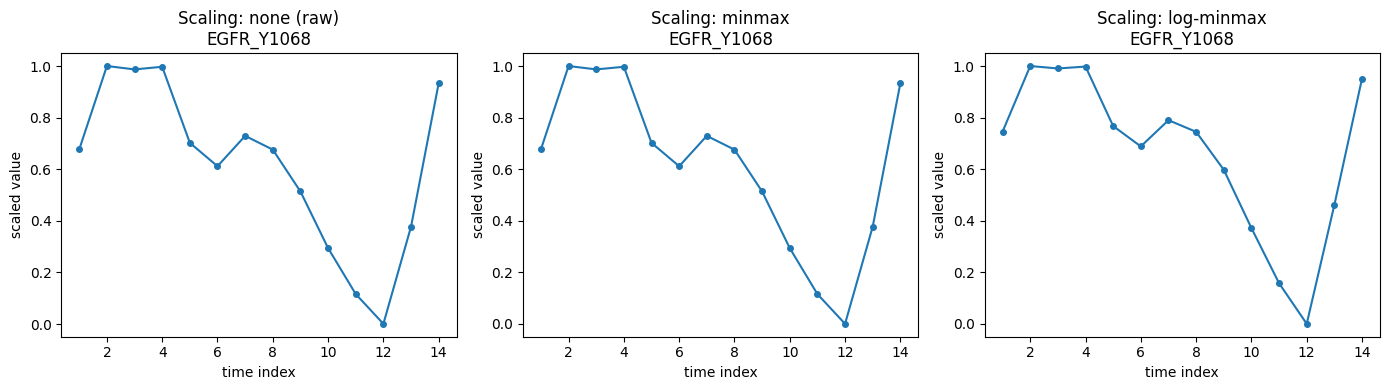

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
site_idx = 0  # show first phosphosite

for ax, (P, title) in zip(axes, [
    (P_none,   "none (raw)"),
    (P_minmax, "minmax"),
    (P_logmm,  "log-minmax"),
]):
    ax.plot(t, P[site_idx], marker="o", markersize=4)
    ax.set_title(f"Scaling: {title}\n{sites[site_idx]}")
    ax.set_xlabel("time index")
    ax.set_ylabel("scaled value")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_scaling_comparison.png", dpi=100)
plt.show()


## 2 · Why scaling matters for ODE fitting

1. **Bounds homogeneity** — all state variables live near [0, 1], so a single
   set of rate bounds applies uniformly.
2. **Loss homogeneity** — without scaling, a high-abundance protein would
   dominate the MSE loss.
3. **Gradient conditioning** — log-space encoding of parameters + minmax data
   keeps Jacobian entries of similar magnitude.


## 3 · Build weight matrices

In [5]:
# Uniform weights — every (site, timepoint) pair gets equal weight
W_data, W_data_prot, W_data_mrna = build_weight_matrices(
    t, P_minmax, A_data,
    t_mrna=t_rna, rna_data=rna_matrix,
    scheme="uniform"
)
print("W_data      shape:", W_data.shape,       "  (N_sites × T)  — phosphosite weights")
print("W_data_prot shape:", W_data_prot.shape,  "  (K × T)         — protein weights")
print("W_data_mrna shape:", W_data_mrna.shape,  "  (K × T_rna)     — mRNA weights")


W_data      shape: (9, 14)   (N_sites × T)  — phosphosite weights
W_data_prot shape: (3, 14)   (K × T)         — protein weights
W_data_mrna shape: (3, 14)   (K × T_rna)     — mRNA weights


In [6]:
# Noise-weighted scheme: down-weights noisy (high-variance) entries
W_noise, W_noise_prot, W_noise_mrna = build_weight_matrices(
    t, P_minmax, A_data,
    t_mrna=t_rna, rna_data=rna_matrix,
    scheme="early_emphasis"
)
print("early_emphasis W_data range:", W_noise.min().round(4), "—", W_noise.max().round(4))
print("uniform        W_data range:", W_data.min().round(4), "—",  W_data.max().round(4))


early_emphasis W_data range: 0.5121 — 1.7028
uniform        W_data range: 1.0 — 1.0


## 4 · Visualise W_data as a heatmap

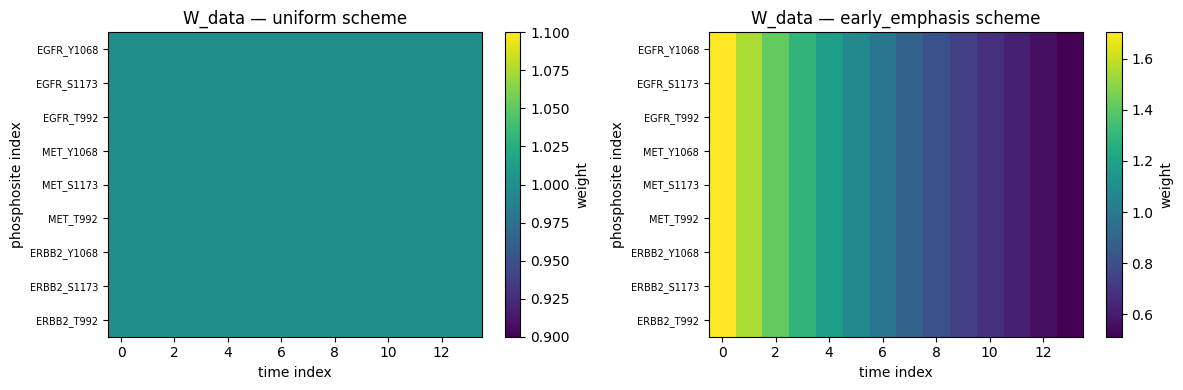

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (W, title) in zip(axes, [
    (W_data,  "uniform"),
    (W_noise, "early_emphasis"),
]):
    im = ax.imshow(W, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_title(f"W_data — {title} scheme")
    ax.set_xlabel("time index")
    ax.set_ylabel("phosphosite index")
    ax.set_yticks(range(len(sites)))
    ax.set_yticklabels(sites, fontsize=7)
    plt.colorbar(im, ax=ax, label="weight")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_weight_heatmaps.png", dpi=100)
plt.show()


## 5 · NaN handling

`build_weight_matrices()` **requires** finite inputs and raises `ValueError` if
any NaN or Inf is present.  Before calling it you must handle missing values
explicitly.  Two recommended patterns:

**Pattern A — impute then mask**: replace NaN with a neutral value (e.g. the
site mean), then build an explicit Boolean mask and zero-out the corresponding
weight entries after construction.

**Pattern B — drop rows/columns**: remove sites or time points with too many
missing values before entering the pipeline.


In [8]:
# Pattern A: impute NaN then zero-out weight entries
Y_with_nan = Y.copy()
Y_with_nan[0, 3] = np.nan   # inject a missing value at site=0, t=3

# Step 1: detect missing positions
nan_mask = np.isnan(Y_with_nan)    # True where data is missing
print('Missing entries:', nan_mask.sum())

# Step 2: impute with site mean so build_weight_matrices does not raise
row_means = np.nanmean(Y_with_nan, axis=1, keepdims=True)
Y_imputed = np.where(nan_mask, row_means, Y_with_nan)
print('Any NaN after imputation:', np.isnan(Y_imputed).any())

# Step 3: build weights on the imputed data (no NaN -> no exception)
W_masked, _, _ = build_weight_matrices(t, Y_imputed, A_data, scheme='uniform')

# Step 4: zero-out the weight at missing positions so they don't affect the loss
W_masked[nan_mask] = 0.0
print('Weight at imputed position (site=0, t=3):', W_masked[0, 3])
print('Weight elsewhere (site=0, t=0)          :', W_masked[0, 0])
print()
print('The missing entry now contributes exactly 0 to the loss,')
print('without any imputation artifact (weight=0 means the residual is ignored).')


Missing entries: 1
Any NaN after imputation: False
Weight at imputed position (site=0, t=3): 0.0
Weight elsewhere (site=0, t=0)          : 1.0

The missing entry now contributes exactly 0 to the loss,
without any imputation artifact (weight=0 means the residual is ignored).
